# Nichenet analysis from ALTRA Bmem C9 to Tmem C3

specific aims: how does Tmem C3 ligand affect the B effector C9?

- ligand from C3
- receptor on C9
- DEG from C9 vs C8


# Setup


In [ ]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library("Seurat")
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("nichenetr")


Warning message:
“Your system is mis-configured: ‘/var/db/timezone/localtime’ is not a symlink”
Warning message:
“‘/var/db/timezone/localtime’ is not identical to any known timezone file”
Warning message:
“Failed to locate timezone database”


In [ ]:
packageVersion("nichenetr")


[1] ‘2.2.0’

In [ ]:
# define file path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction"
fig_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/nichenet"
ref_path <- "/home/workspace/private/reference_data/nichenet"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "ALTRA_Nichenet_Beff_to_TmemC3"


In [ ]:
# define the color palette to be used
npg_color <- c(
    "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
    "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
    "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


In [ ]:
# load nichenet ligand-receptor database
lr_network <- readRDS(file.path(ref_path, "lr_network_human_21122021.rds"))
ligand_target_matrix <- readRDS(file.path(ref_path, "ligand_target_matrix_nsga2r_final.rds"))
weighted_networks <- readRDS(file.path(ref_path, "weighted_networks_nsga2r_final.rds"))


# Signal send fromB effector to Tmem C3


In [ ]:
# load gene list expressed by Tmem C3
TmemC3_genes <-
    read_csv(file.path(data_path, "ALTRA_TmemC3_expressed_genes.csv"),
        show_col_types = FALSE
    )
TmemC3_genes %>% head()
# load gene list expressed by Beff C9
BeffC9_genes <-
    read_csv(file.path(data_path, "ALTRA_BeffC9_expressed_genes.csv"),
        show_col_types = FALSE
    )
BeffC9_genes %>% head()


New names:
• `` -> `...1`


...1,genes,props,cell_type
<dbl>,<chr>,<dbl>,<chr>
32030,A1BG,0.1491139,CD4mem_C3
16365,AAED1,0.1186709,CD4mem_C3
3829,AAK1,0.7283544,CD4mem_C3
5117,AAMP,0.1450000,CD4mem_C3
7595,AASDH,0.1162658,CD4mem_C3
18506,AASDHPPT,0.2198101,CD4mem_C3


New names:
• `` -> `...1`


...1,genes,props,cell_type
<dbl>,<chr>,<dbl>,<chr>
32030,A1BG,0.1599073,CD27- effector B cell_C9
16365,AAED1,0.1123986,CD27- effector B cell_C9
5117,AAMP,0.1517961,CD27- effector B cell_C9
18506,AASDHPPT,0.1958285,CD27- effector B cell_C9
27428,AATF,0.3059096,CD27- effector B cell_C9
8189,ABCE1,0.1865585,CD27- effector B cell_C9


In [ ]:
# align the gene symbols
# define the sender and receiver genes
expressed_genes_sender <- BeffC9_genes$genes
expressed_genes_receiver <- TmemC3_genes$genes
# If this is not done, there will be 35 genes fewer in lr_network_expressed!
expressed_genes_sender <- convert_alias_to_symbols(expressed_genes_sender,
    "human",
    verbose = TRUE
)
expressed_genes_receiver <- convert_alias_to_symbols(expressed_genes_receiver,
    "human",
    verbose = TRUE
)


[1] "there are provided symbols that are not in the alias annotation table: "
 [1] "AC004687.1" "AC005332.5" "AC007388.1" "AC007952.4" "AC010642.2"
 [6] "AC012236.1" "AC013394.1" "AC016831.7" "AC025164.1" "AC027097.1"
[11] "AC058791.1" "AC079630.1" "AC087190.1" "AC090152.1" "AC092683.1"
[16] "AC096733.2" "AC100810.1" "AC103591.3" "AC114760.2" "AC119428.2"
[21] "AC243960.1" "AC245060.5" "AC245297.3" "AL662796.1" "AL662844.4"
[26] "AP001157.1" "CXorf21"    "GARS"       "MPP6"       "POLR2J3-1" 
[31] "QARS"       "SARS"       "SEPT2"      "TAZ"       
[1] "they are added to the alias annotation table, so they don't get lost"
[1] "following are the official gene symbols of input aliases: "
       symbol     alias
1       ADSS2      ADSS
2      ANTKMT   FAM173A
3      ATP5MJ   ATP5MPL
4      ATP5MK    ATP5MD
5        BBLN   C9orf16
6       CERT1  COL4A3BP
7      CIAO2A    FAM96A
8      CIAO2B    FAM96B
9        COA8    APOPT1
10      CYRIA    FAM49A
11      CYRIB    FAM49B
12       CZIB  C1

In [ ]:
# filter the expressed ligands and receptors to only those that putatively bind together
ligands <- lr_network %>%
  pull(from) %>%
  unique()
expressed_ligands <- intersect(ligands, expressed_genes_sender)

receptors <- lr_network %>%
  pull(to) %>%
  unique()
expressed_receptors <- intersect(receptors, expressed_genes_receiver)

potential_ligands <- lr_network %>%
  filter(from %in% expressed_ligands & to %in% expressed_receptors) %>%
  pull(from) %>%
  unique()

length(potential_ligands)


[1] 71

In [ ]:
c3_degs <- read_csv(file.path(output_path, "CD4T_mem_certpro_DEGs_wilcoxon_res_0.4_CLUSTER_3_Filtered_vs_Rest_py.csv"))


New names:
• `` -> `...1`
Rows: 33538 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): names, direction
dbl (5): ...1, scores, logfoldchanges, pvals, pvals_adj

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
geneset_oi <- c3_degs %>%
    filter(pvals_adj < 0.01 & abs(logfoldchanges) > 1) %>%
    pull(names)
geneset_oi <- convert_alias_to_symbols(geneset_oi, "human", verbose = TRUE)
geneset_oi %>% length()


[1] "there are provided symbols that are not in the alias annotation table: "
 [1] "AP002884.1" "AC004585.1" "AC133644.2" "AC090152.1" "AC009041.1"
 [6] "AC009041.2" "AC001226.2" "CXorf21"    "AL391097.1" "AL023584.2"
[1] "they are added to the alias annotation table, so they don't get lost"
[1] "following are the official gene symbols of input aliases: "
    symbol     alias
1   FHIP2A  FAM160B1
2    H2BC9 HIST1H2BH
3  MARCHF3    MARCH3
4 SEPTIN10    SEPT10


[1] 232

In [ ]:
background_expressed_genes <- expressed_genes_receiver %>% .[. %in% rownames(ligand_target_matrix)]
background_expressed_genes <- background_expressed_genes[!background_expressed_genes %in% geneset_oi]
length(background_expressed_genes)


[1] 5224

In [ ]:
ligand_activities <- predict_ligand_activities(
  geneset = geneset_oi,
  background_expressed_genes = background_expressed_genes,
  ligand_target_matrix = ligand_target_matrix,
  potential_ligands = potential_ligands
)
ligand_activities <- ligand_activities %>%
  arrange(-aupr_corrected) %>%
  mutate(rank = rank(desc(aupr_corrected)))
ligand_activities


test_ligand,auroc,aupr,aupr_corrected,pearson,rank
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TGFB1,0.6305288,0.08839315,0.04780546,0.13523751,1
IL7,0.6010330,0.08297472,0.04238702,0.08593314,2
HLA-A,0.5676897,0.07712304,0.03653534,0.08577345,3
CD86,0.5555147,0.07525636,0.03466867,0.08722779,4
ZDHHC5,0.5765792,0.07100364,0.03041594,0.05414971,5
HLA-DQB1,0.5509734,0.07072530,0.03013761,0.04755923,6
B2M,0.5613424,0.07024581,0.02965812,0.06418504,7
BACE2,0.5910044,0.07013349,0.02954580,0.07868423,8
S100A8,0.5664476,0.06989670,0.02930900,0.06935464,9


In [ ]:
ligand_activities %>% write_csv(file.path(output_path, paste0(
    proj_name,
    "nichenet_results.csv"
)))


In [ ]:
file.path(output_path, paste0(proj_name, "nichenet_results.csv"))


[1] "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/nichenet/ALTRA_Nichenet_Beff_to_TmemC3nichenet_results.csv"

In [ ]:
best_upstream_ligands <- ligand_activities %>%
  top_n(25, aupr_corrected) %>%
  arrange(-aupr_corrected) %>%
  pull(test_ligand)


In [ ]:
ligand_oi <- c(
    "IL7", "CD86", "HLA-DQB1", "S100A8",
    "CCL5", "CD72", "HLA-DRB1", "CD48"
)
best_upstream_ligands <- ligand_activities %>%
    filter(test_ligand %in% ligand_oi) %>%
    pull(test_ligand)


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


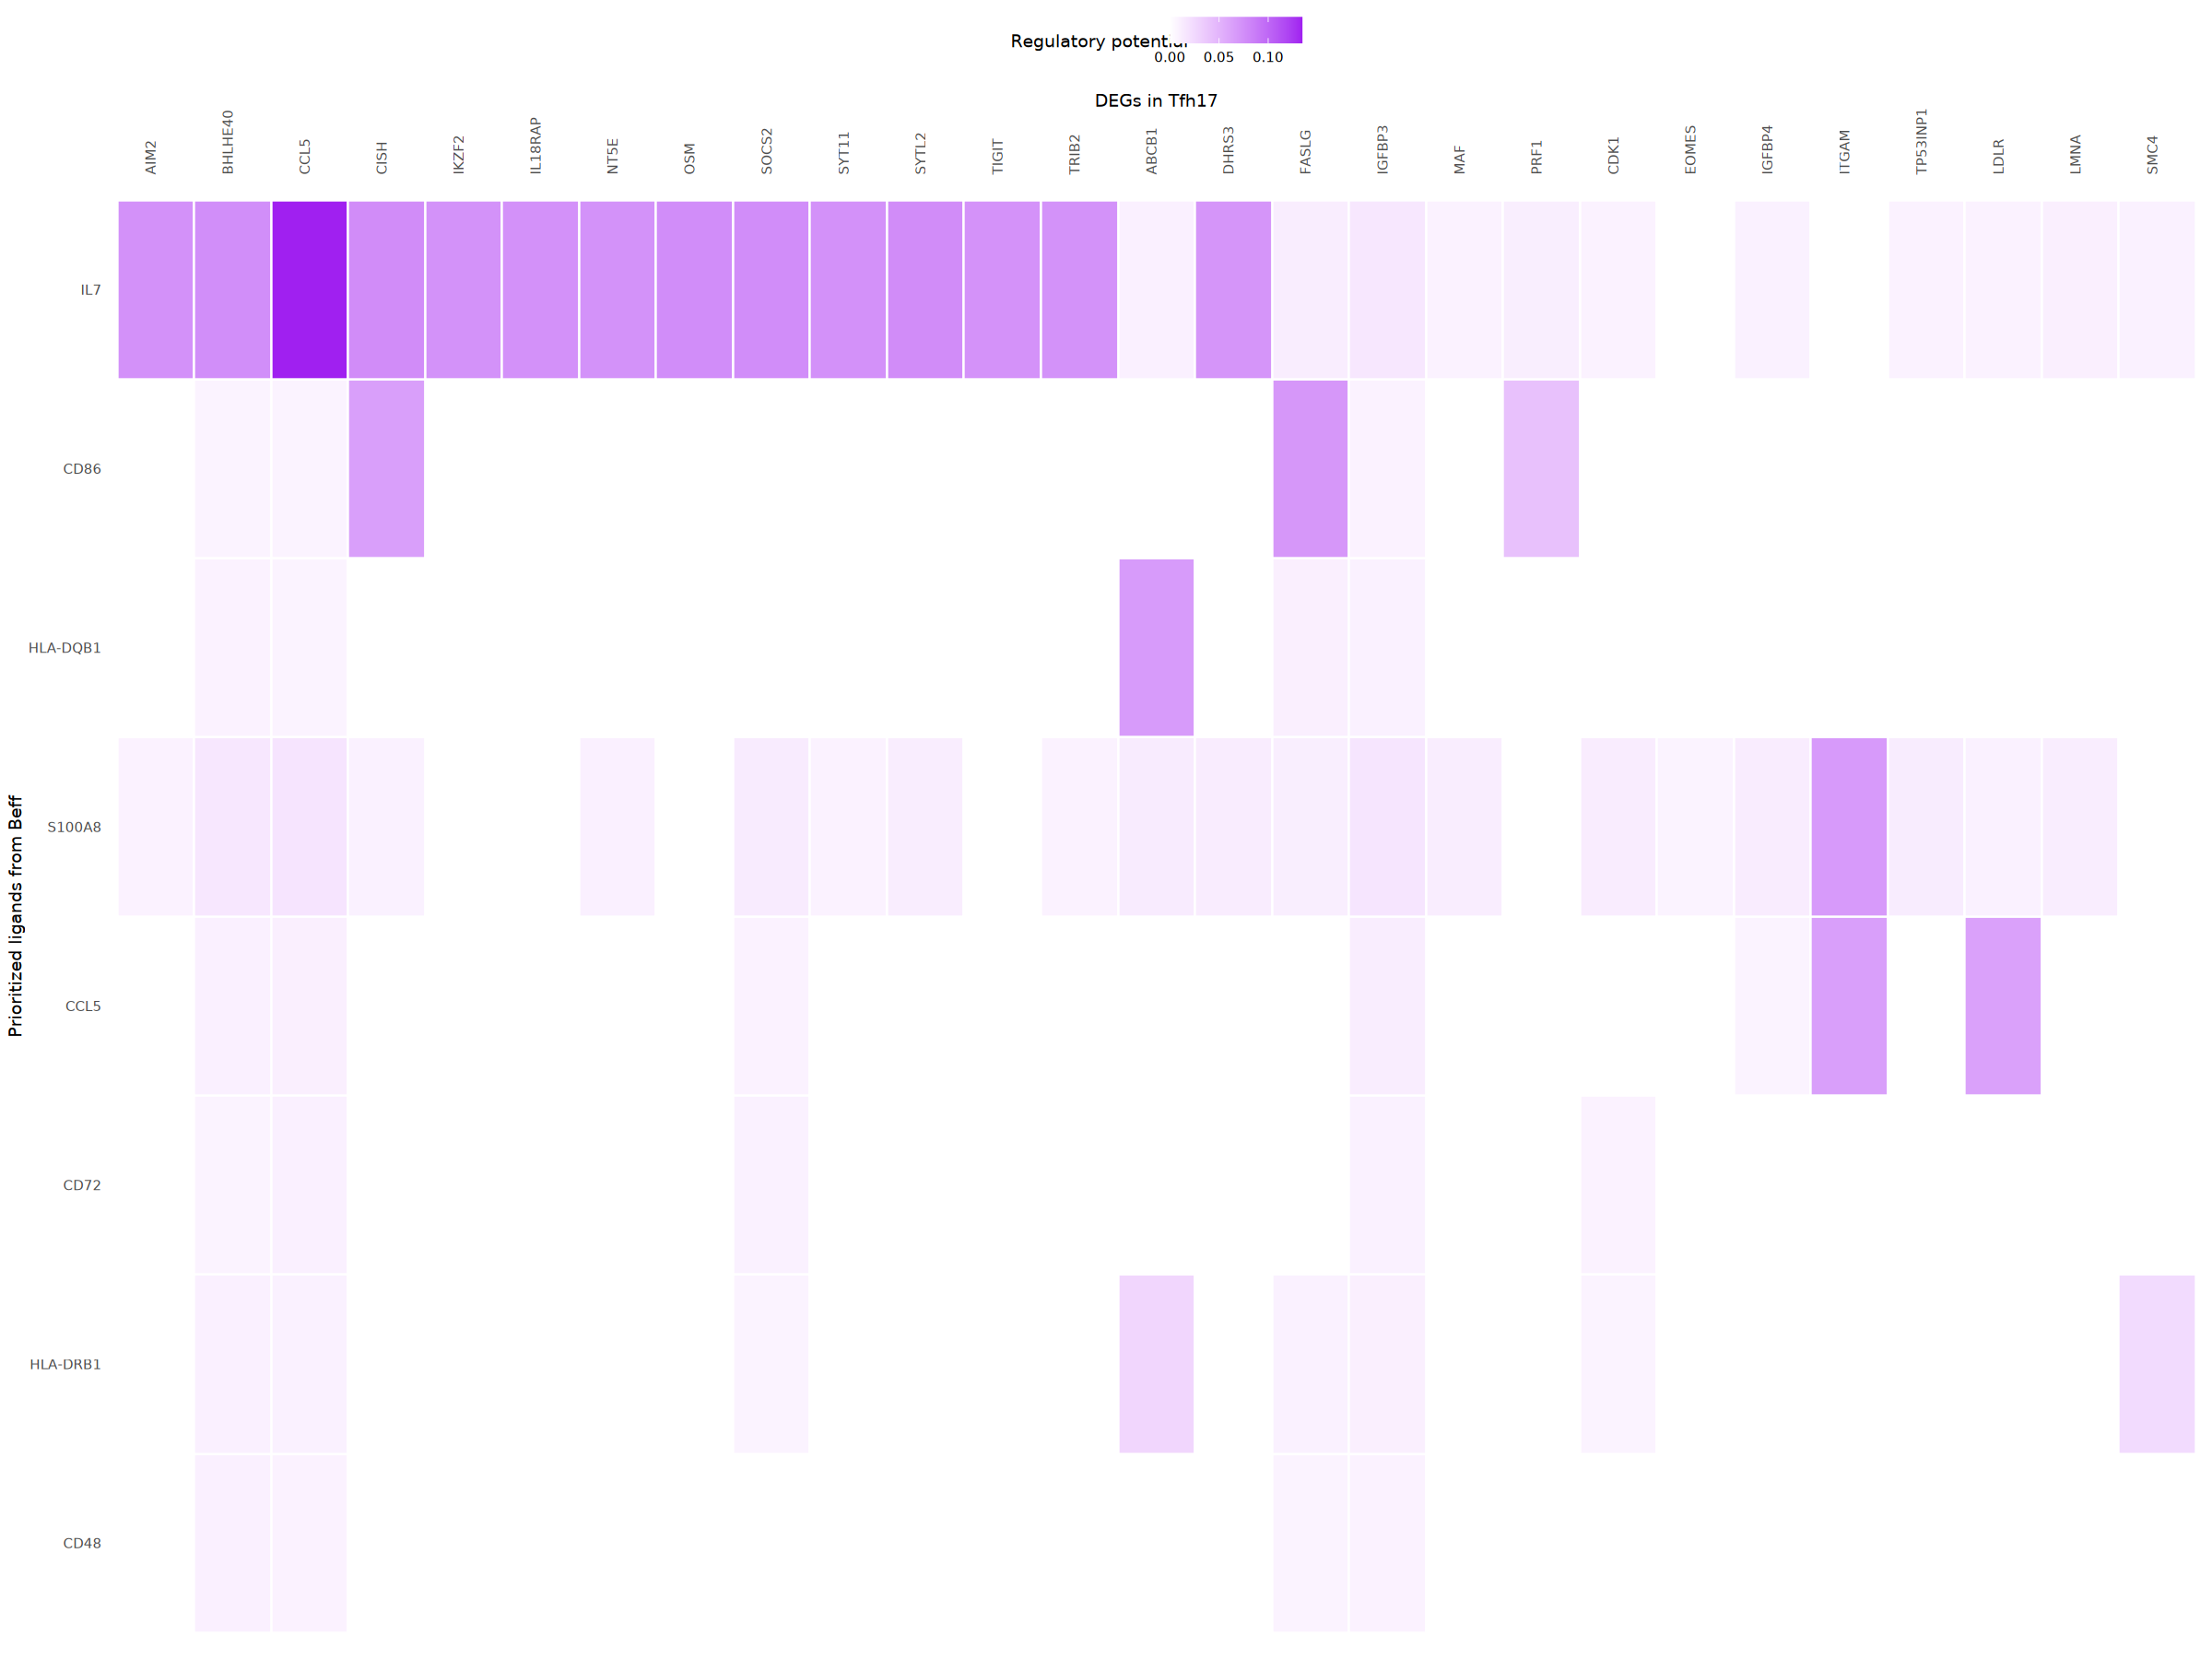

In [ ]:
active_ligand_target_links_df <- best_upstream_ligands %>%
  lapply(get_weighted_ligand_target_links,
    geneset = geneset_oi,
    ligand_target_matrix = ligand_target_matrix,
    n = 200
  ) %>%
  bind_rows()

active_ligand_target_links <- prepare_ligand_target_visualization(
  ligand_target_df = active_ligand_target_links_df,
  ligand_target_matrix = ligand_target_matrix,
  cutoff = 0.25
)

order_ligands <- intersect(best_upstream_ligands, colnames(active_ligand_target_links)) %>% rev()
order_targets <- active_ligand_target_links_df$target %>%
  unique() %>%
  intersect(rownames(active_ligand_target_links))

vis_ligand_target <- t(active_ligand_target_links[order_targets, order_ligands])

p_ligand_target_network <- make_heatmap_ggplot(vis_ligand_target, "Prioritized ligands from Beff",
  "DEGs in Tfh17",
  color = "purple", legend_title = "Regulatory potential"
) +
  scale_fill_gradient2(low = "whitesmoke", high = "purple")

p_ligand_target_network
ggsave(file.path(fig_path, paste0(proj_name, "_ligand_target_genes.pdf")), width = 6, height = 4 * 0.8)


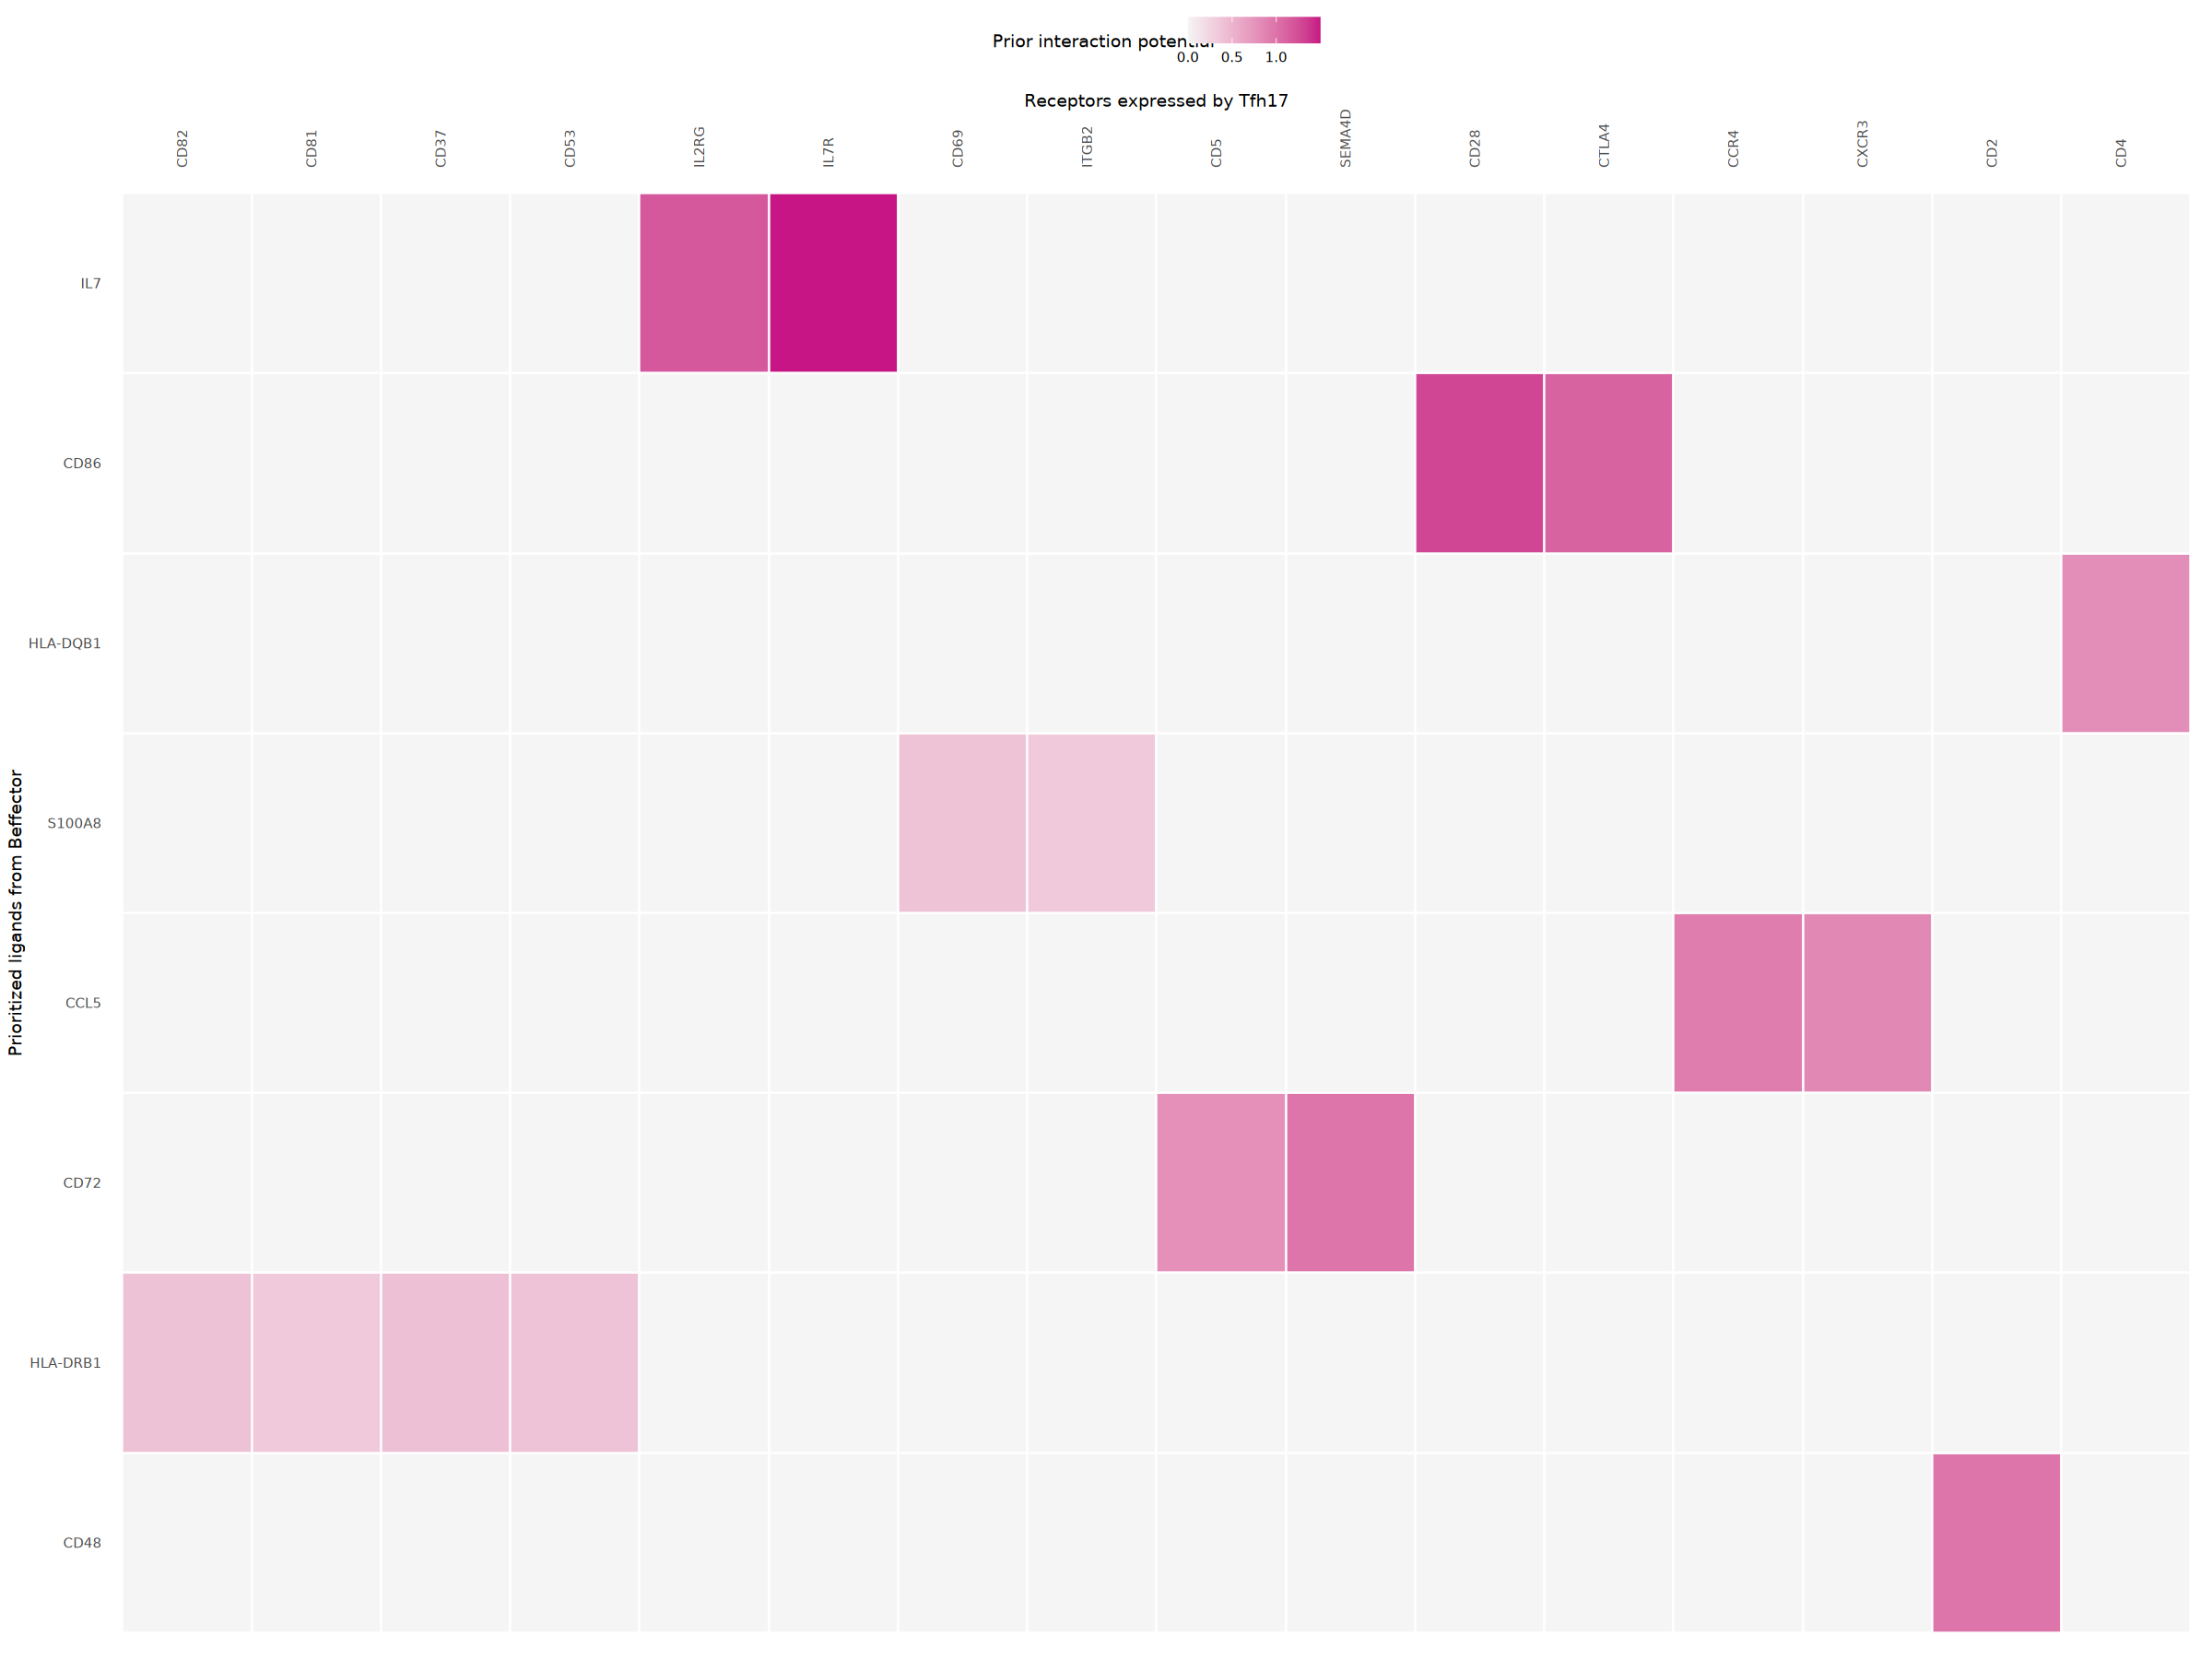

In [ ]:
# plot the ligand receptor relationship
ligand_receptor_links_df <- get_weighted_ligand_receptor_links(
  best_upstream_ligands, expressed_receptors,
  lr_network, weighted_networks$lr_sig
)

vis_ligand_receptor_network <- prepare_ligand_receptor_visualization(
  ligand_receptor_links_df,
  best_upstream_ligands,
  order_hclust = "receptors"
)

(make_heatmap_ggplot(t(vis_ligand_receptor_network),
  y_name = "Prioritized ligands from Beffector", x_name = "Receptors expressed by Tfh17",
  color = "mediumvioletred", legend_title = "Prior interaction potential"
))
ggsave(file.path(fig_path, paste0(proj_name, "_ligand_receptor_genes.png")), width = 8, height = 6)
